## Extract Sphere SAXS curve from GSD file

##### Initialize sasintensity instance

In [ ]:
#import necessary modules
import sys
sys.path.append('../gsd2sas')
import os
import re
import csv
import numpy as np
import matplotlib.pyplot as plt
from sasintensity import SphereIntensity
import matplotlib.ticker as ticker


In [5]:
def extract_params_from_filename(filename):
    match = re.search(
        r"N([\d.]+)_phi(\d+\.\d{3})_epsd([\d.]+)_delta([\d.]+)_epsY([\d.]+)_lamb([\d.]+)",
        filename
    )
    if match:
        try:
            return tuple(float(x.rstrip('.')) for x in match.groups())
        except ValueError:
            return None
    return None

In [6]:
def compute_structure_factor(gsd_path, volume_fraction=0.01, sld_sample=118e-6, sld_solvent=9.44e-6, radius=10, frame=1):
    au = SphereIntensity(volume_fraction=volume_fraction, sld_sample=sld_sample, sld_solvent=sld_solvent)
    au.set_form_factor(radius=radius)
    au.set_structure_factor(gsd_path=gsd_path, N_grid=300, frame=frame)
    q, s = au.scale_s_1d()
    return q[1:-1], s[1:-1]  # Skip first and last bin

In [ ]:
# Set up paths
root_directory = "/Users/dadanzhang/Desktop/Z lab/projects/CSSAS/"
folder_pattern = re.compile(r"delta\d+\.\d+_epsY\d+\.\d+_lamb\d+\.\d+")
output_txt = "structure_factor_summary.txt"
output_data = []

In [ ]:
# Main processing loop
for folder in os.listdir(root_directory):
    folder_path = os.path.join(root_directory, folder)
    if os.path.isdir(folder_path) and folder_pattern.fullmatch(folder):
        for filename in os.listdir(folder_path):
            if filename.startswith("N") and filename.endswith(".gsd"):
                params = extract_params_from_filename(filename)
                if params is None:
                    continue

                gsd_path = os.path.join(folder_path, filename)
                print(f"Processing {gsd_path}")
                try:
                    q_vals, s_vals = compute_structure_factor(gsd_path)

                    # Save structure factor plot
                    plot_filename = f"S_q_N{params[0]}_phi{params[1]}_epsd{params[2]}_delta{params[3]}_epsY{params[4]}_lamb{params[5]}.png"
                    plt.figure()
                    plt.plot(q_vals, s_vals, label='S(q)')
                    plt.xlabel('q ($\\AA^{-1}$)')
                    plt.ylabel('S(q)')
                    plt.title(f'Structure Factor')
                    plt.tight_layout()
                    plt.savefig(os.path.join(folder_path, plot_filename))
                    plt.close()

                    # Append data for text file
                    for q, s in zip(q_vals, s_vals):
                        output_data.append([*params, s, q])

                except Exception as e:
                    print(f"Error processing {filename}: {e}")

# Save structure factor data to txt
with open(output_txt, "w", newline='') as f_out:
    writer = csv.writer(f_out, delimiter='\t')
    writer.writerow(['N', 'phi', 'epsd', 'delta', 'epsY', 'lamb', 'S', 'q'])
    for row in output_data:
        writer.writerow(row)

In [2]:
# Create an instance of the SphereIntensity class, corresponding to SAXS curve of spheres
# SLD of samples and solvent can be found in literature
au = SphereIntensity(volume_fraction=0.01, sld_sample=118e-6, sld_solvent=9.44e-6)

In [3]:
# Initialize form factor, unit is nm
au.set_form_factor(radius=10)

# Initialize structure factor, which requises the gsd file, N_grid, and what frames to extract
gsd = '/Users/dadanzhang/Desktop/Z lab/projects/CSSAS/delta0.25_epsY0.73_lamb4.28/N8000.0_phi0.010_epsd7.10_delta0.25_epsY0.73_lamb4.28.gsd'
au.set_structure_factor(gsd_path=gsd, N_grid=300, frame=1)

##### Compute Structure Factor(Optional)

In [4]:
q, s = au.scale_s_1d()

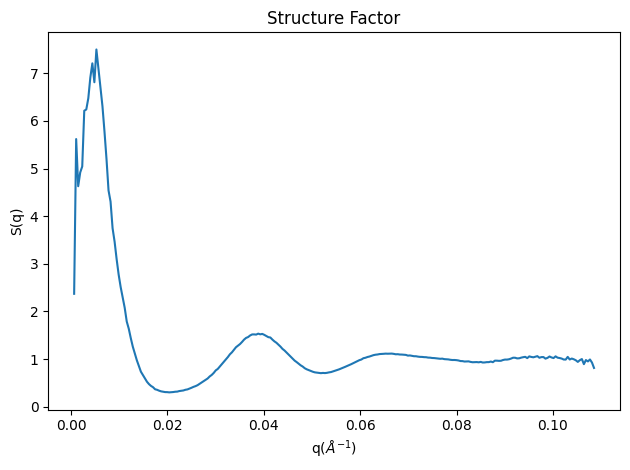

In [5]:
# the first bin of q&s need to be removed
plt.plot(q[1:-1], s[1:-1], label='S(q)')
plt.xlabel('q($\AA^{-1}$)')
plt.ylabel('S(q)')
plt.title('Structure Factor')
plt.tight_layout()

#### Compute Form Factor(Optional)

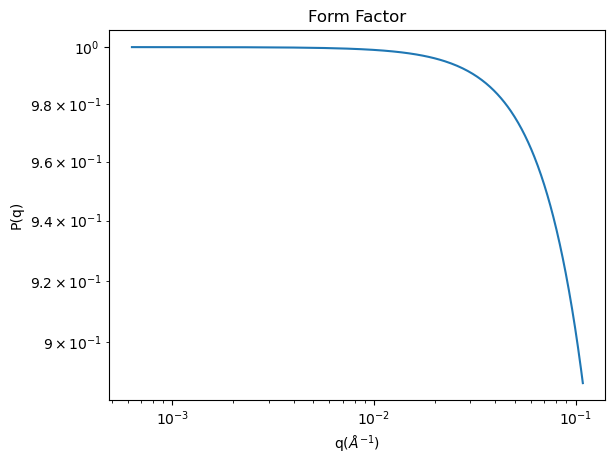

In [7]:
# Form factor of sphere is analytic, the input needs to match the one from structure factor.
p = au.form_factor.Compute_Fq(q)
plt.loglog(q[1:-1],p[1:-1])
#plt.xlim(0.04, 10)
plt.xlabel('q($\AA^{-1}$)')
plt.ylabel('P(q)')
plt.title('Form Factor')
plt.yscale('log')

##### Compute Iq

In [8]:
q, Iq = au.compute_Iq()

Text(0.5, 1.0, 'Extracted Intensity')

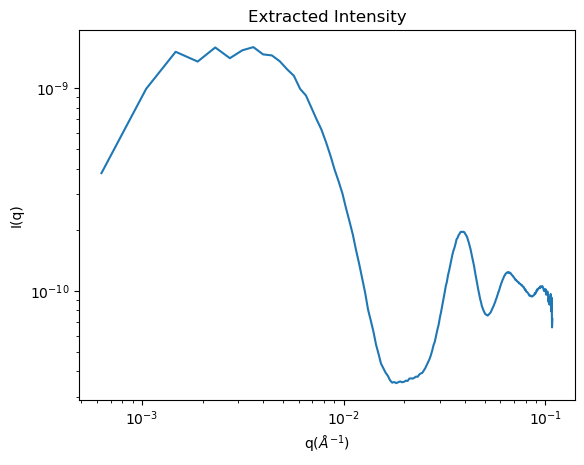

In [9]:
plt.loglog(q[1:-1], Iq[1:-1])
plt.xlabel('q($\AA^{-1}$)')
plt.ylabel('I(q)')
plt.title('Extracted Intensity')
#plt.xlim(0.04,0.1)